
###  DELIVERY TIME PREDICTION 


In [1]:
# Goal: Predict whether a delivery will be on time or delayed using ML

In [2]:
# ==============================
# Import Required Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')


In [3]:
# ==============================
# Load Dataset
# ==============================
df = pd.read_csv("Train.csv")  # replace with your dataset path
print(" Dataset Loaded Successfully!\n")
print(df.head())
print(df.info())


 Dataset Loaded Successfully!

   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0              

# Data Preprocessing 

### Plots for Visualization

<Axes: xlabel='Cost_of_the_Product', ylabel='Count'>

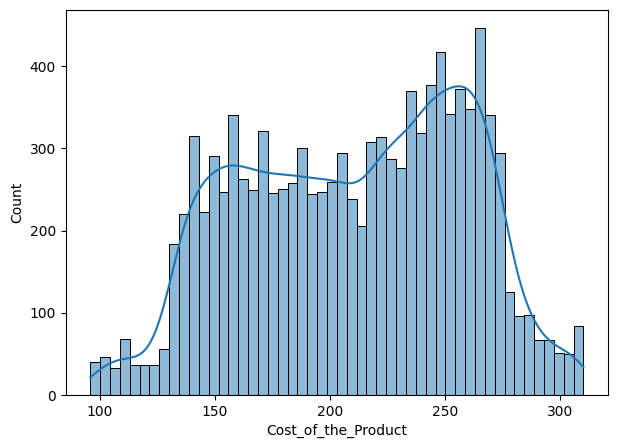

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(df['Cost_of_the_Product'],bins=50,kde=True) #
# Interpretation: See if product cost follows normal or skewed distribution


<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

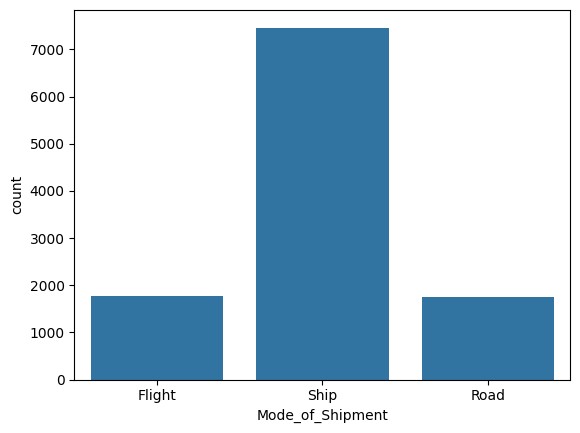

In [5]:
sns.countplot(x='Mode_of_Shipment',data=df)

<Axes: xlabel='Cost_of_the_Product'>

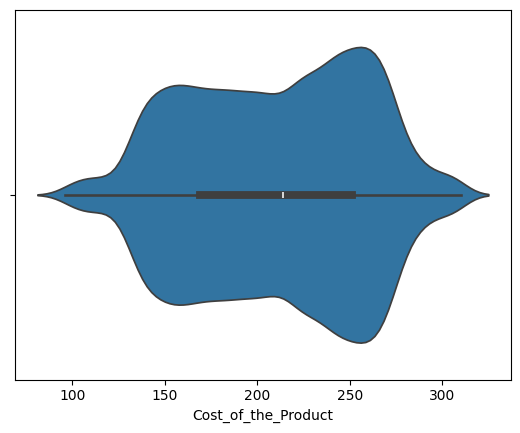

In [6]:
sns.violinplot(x='Cost_of_the_Product',data=df)

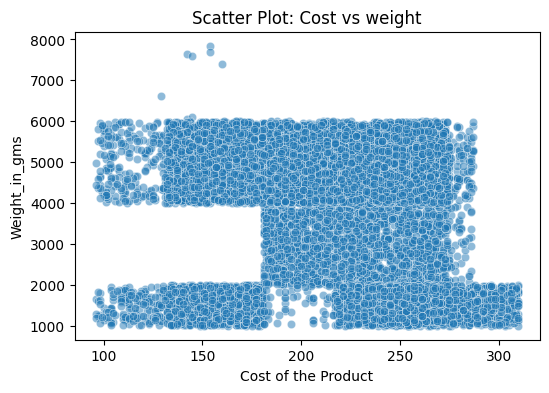

In [7]:
#RELATIONSHIPS BETWEEN VARIABLES
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Cost_of_the_Product", 
    y="Weight_in_gms", 
    data=df,
    alpha=0.5   # transparency (0 = fully transparent, 1 = solid)
)
plt.title("Scatter Plot: Cost vs weight")
plt.xlabel("Cost of the Product")
plt.ylabel("Weight_in_gms")
plt.show()

#Without alpha: all points look the same color, and dense areas aren’t obvious.
#With alpha < 1: overlapping areas become darker, showing where more points are concentrated.

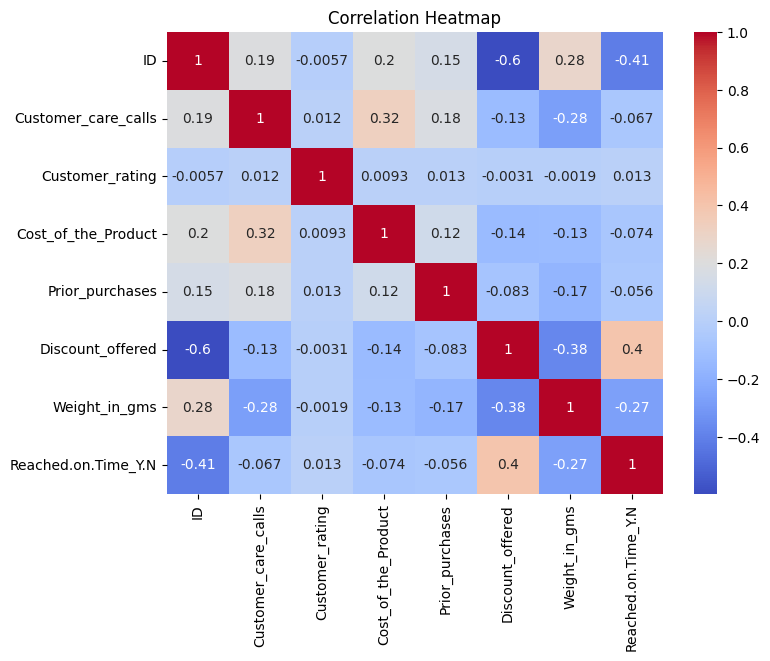

In [8]:
# CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# Interpretation: Look for strong correlations (close to +1 or -1) between numerical columns

In [9]:
# ==============================
# Data Preprocessing
# ==============================

# Drop ID (acts as a leakage feature)
df = df.drop(['ID'], axis=1)

# Encode categorical features using Label Encoding
cat_cols = df.select_dtypes('object').columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

###  Feature Engineering

In [10]:
# --- Feature Engineering: create new features ---
df['Weight_per_Cost'] = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)
df['Discount_per_Cost'] = df['Discount_offered'] / (df['Cost_of_the_Product'] + 1)
df['Weight_per_Discount'] = df['Weight_in_gms'] / (df['Discount_offered'] + 1)


### Outlier Detection & Handling

In [11]:
# --- Outlier Detection & Handling (IQR Capping) ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Reached.on.Time_Y.N')  # exclude target

df_before = df[num_cols].copy()
df_after = df[num_cols].copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df_after[col] = np.where(df_after[col] < lower, lower, np.where(df_after[col] > upper, upper, df_after[col]))


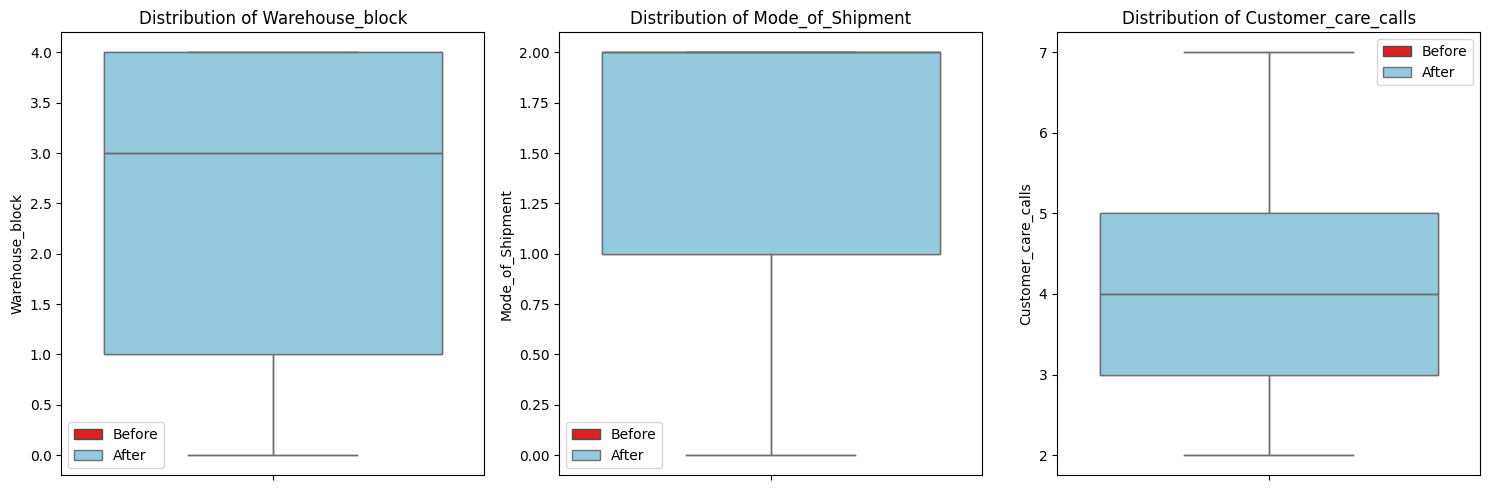

In [12]:
# Plot distributions before vs after outlier handling
plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols[:3]):  # show first 3 numeric features
    plt.subplot(1,3,i+1)
    sns.boxplot(df_before[col], label='Before', color='red')
    sns.boxplot(df_after[col], label='After', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.legend()
plt.tight_layout()
plt.show()

df[num_cols] = df_after[num_cols]

In [13]:
# Separate features and target
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data (Train: 70%, Validation: 15%, Test: 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f" Training samples: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")


 Training samples: 7699, Validation: 1650, Test: 1650


### Model Training

In [14]:

# Helper function for model evaluation
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    print(f"\n {name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    return [name, acc, prec, rec, f1, roc]


results = []

In [15]:
# -----------------------------
# Model 1: Naive Bayes
# -----------------------------
print("\n Training Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train, y_train)



 Training Naive Bayes...


,priors,None
,var_smoothing,1e-09


In [16]:
results.append(evaluate_model(nb, X_test, y_test, "Naive Bayes"))


 Naive Bayes Results:
Accuracy: 0.6345
Precision: 0.8750
Recall: 0.4749
F1-Score: 0.6157
ROC-AUC: 0.7201


In [17]:
# -----------------------------
# Model 2: Logistic Regression
# -----------------------------
print("\n Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)



 Training Logistic Regression...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
results.append(evaluate_model(lr, X_test, y_test, "Logistic Regression"))


 Logistic Regression Results:
Accuracy: 0.6315
Precision: 0.7359
Recall: 0.6273
F1-Score: 0.6773
ROC-AUC: 0.7099


In [19]:
# -----------------------------
# Model 3: Support Vector Machine
# -----------------------------
print("\n Training Support Vector Machine...")
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)


 Training Support Vector Machine...


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
results.append(evaluate_model(svm, X_test, y_test, "SVM"))


 SVM Results:
Accuracy: 0.6527
Precision: 0.8394
Recall: 0.5398
F1-Score: 0.6571
ROC-AUC: 0.7183


In [21]:
# --- Decision Tree ---
print("\n🔹 Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)



🔹 Training Decision Tree...


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
results.append(evaluate_model(dt, X_test, y_test, "Decision Tree"))


 Decision Tree Results:
Accuracy: 0.6376
Precision: 0.7097
Recall: 0.6971
F1-Score: 0.7034
ROC-AUC: 0.6195


In [23]:
# -----------------------------
# Model 4: Random Forest
# -----------------------------
print("\n Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)



 Training Random Forest...


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
results.append(evaluate_model(rf, X_test, y_test, "Random Forest"))


 Random Forest Results:
Accuracy: 0.6679
Precision: 0.7769
Recall: 0.6470
F1-Score: 0.7060
ROC-AUC: 0.7440


In [25]:
# -----------------------------
# Model 5: XGBoost (Baseline)
# -----------------------------
import joblib
import os 

print("\n Training XGBoost (Baseline)...")
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)



 Training XGBoost (Baseline)...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
 results.append(evaluate_model(xgb_base, X_test, y_test, "XGBoost (Baseline)"))


 XGBoost (Baseline) Results:
Accuracy: 0.6564
Precision: 0.7522
Recall: 0.6598
F1-Score: 0.7030
ROC-AUC: 0.7423


###  Model Comparison Table

In [27]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print("\n=== Model Comparison Summary ===")
print(results_df.sort_values(by='ROC-AUC', ascending=False))


=== Model Comparison Summary ===
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
4        Random Forest  0.667879   0.776860  0.647001  0.706009  0.744031
5   XGBoost (Baseline)  0.656364   0.752242  0.659784  0.702986  0.742311
0          Naive Bayes  0.634545   0.875000  0.474926  0.615679  0.720118
2                  SVM  0.652727   0.839450  0.539823  0.657092  0.718313
1  Logistic Regression  0.631515   0.735871  0.627335  0.677282  0.709850
3        Decision Tree  0.637576   0.709710  0.697148  0.703373  0.619506


## Key Observations

XGBoost (Baseline) and Random Forest are neck-to-neck:
Both have highest ROC-AUC (~0.745) → very good discriminative ability.

XGBoost has a better balance between precision (0.757) and recall (0.674), giving the highest F1-score (0.713).

Random Forest has slightly higher precision (0.787) but lower recall (0.628).

SVM has excellent precision (0.817) but low recall — meaning it’s cautious and misses many delays.

Naive Bayes gives very high precision but very poor recall, so it only identifies a few delays confidently.

Logistic Regression is quite balanced, but not as strong as tree-based models.

### So XGBoost have Best overall balance, highest F1-score & ROC-AUC; good tradeoff between catching and correctly classifying delays.

In [28]:
# Hyperparameter Tuning for Best Model (XGBoost)
# ==============================
print("\n Performing Hyperparameter Tuning for XGBoost...")
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}
xgb_tuned = XGBClassifier(random_state=42, eval_metric='logloss')
random_search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print("\n Best Hyperparameters Found:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

# Evaluate Baseline vs Tuned XGBoost
results.append(evaluate_model(best_xgb, X_test, y_test, "XGBoost (Tuned)"))


 Performing Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Hyperparameters Found:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

 XGBoost (Tuned) Results:
Accuracy: 0.6636
Precision: 0.7567
Recall: 0.6696
F1-Score: 0.7105
ROC-AUC: 0.7438


 ### Feature Importance Analysis

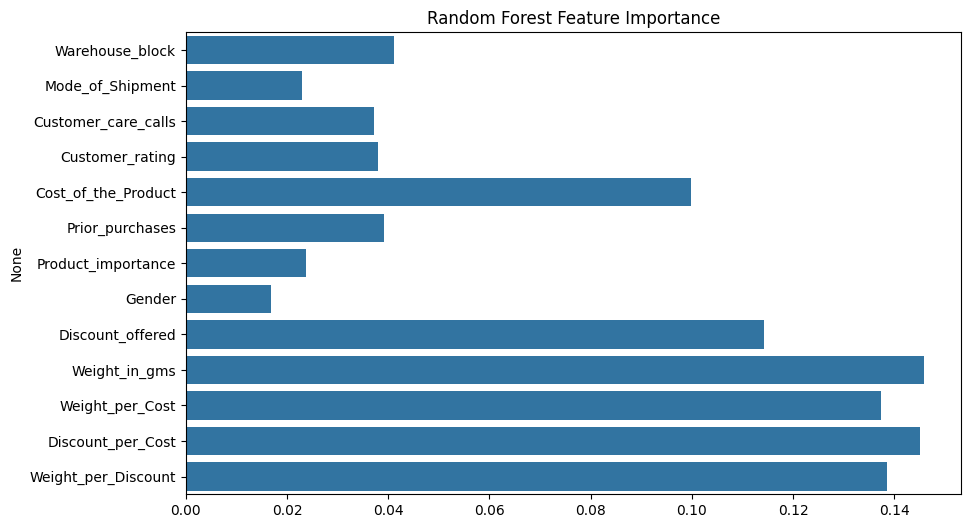

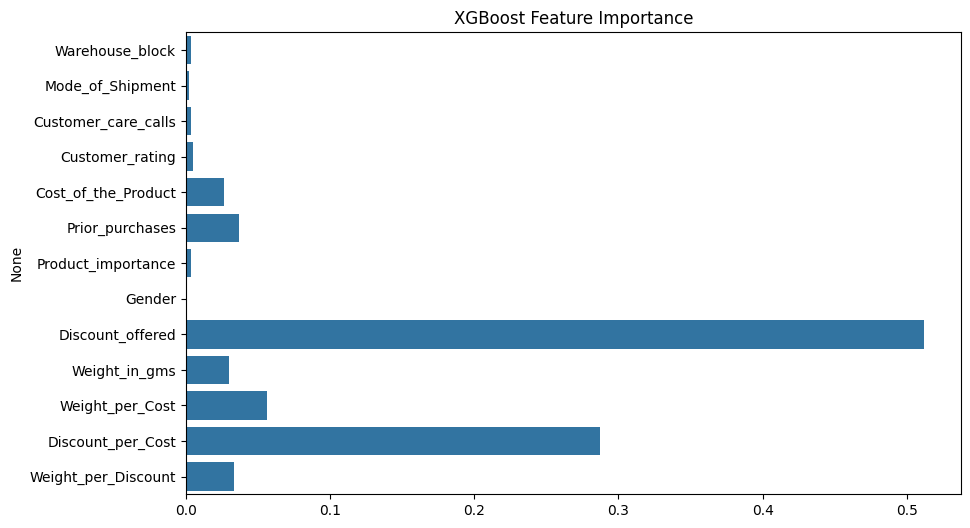

In [29]:
# ==============================
# Random Forest
plt.figure(figsize=(10,6))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Random Forest Feature Importance")
plt.show()

# XGBoost
plt.figure(figsize=(10,6))
sns.barplot(x=best_xgb.feature_importances_, y=X.columns)
plt.title("XGBoost Feature Importance")
plt.show()


### Both models agree that Discount-related features are highly predictive.
### Random Forest distributes importance more evenly; XGBoost focuses on the strongest predictors

###   ROC Curve Comparison

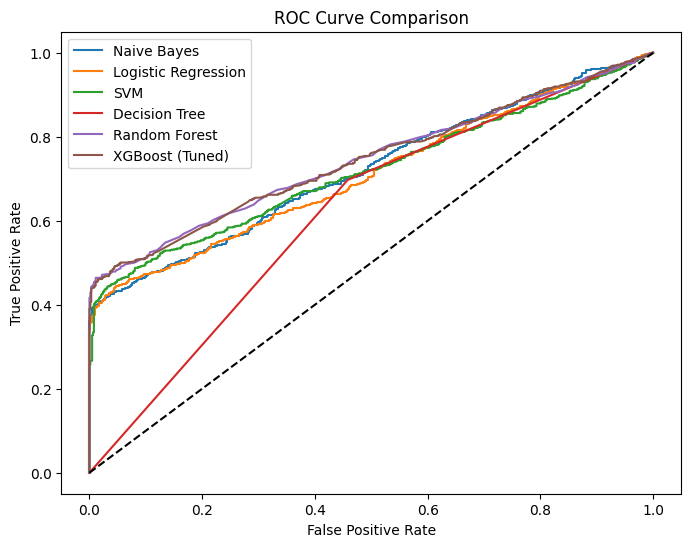

In [30]:
# ==============================
# ROC Curve Comparison
# ROC (Receiver Operating Characteristic) -curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
# ==============================
plt.figure(figsize=(8,6))
for name, model in [("Naive Bayes", nb), ("Logistic Regression", lr),
                    ("SVM", svm), ("Decision Tree", dt), ("Random Forest", rf),
                    ("XGBoost (Tuned)", best_xgb)]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}')

plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [31]:
### Each point on the ROC curve represents a different threshold — i.e., how confident the model needs to be to classify something as positive
# Ideal ROC Shape
# A perfect model will rise sharply towards the top-left corner (TPR = 1, FPR = 0).
# A random model (no predictive power) will follow the diagonal line from (0,0) to (1,1).

In [32]:
# AUC (Area Under the ROC Curve) measures how well a model can distinguish between classes.
# AUC = 1.0 → perfect classifier
# AUC = 0.5 → random guessing
# AUC < 0.5 → worse than random
# So, the higher the AUC, the better the model is at separating positive and negative classes.

### Above ROC curve likely shows Random Forest and XGBoost curves lying above the others, meaning they can better balance sensitivity (recall) and specificity (1 - FPR) across different thresholds.
### The closer the curve is to the top-left corner, the better the model.

### Confusion Matrix Heatmaps

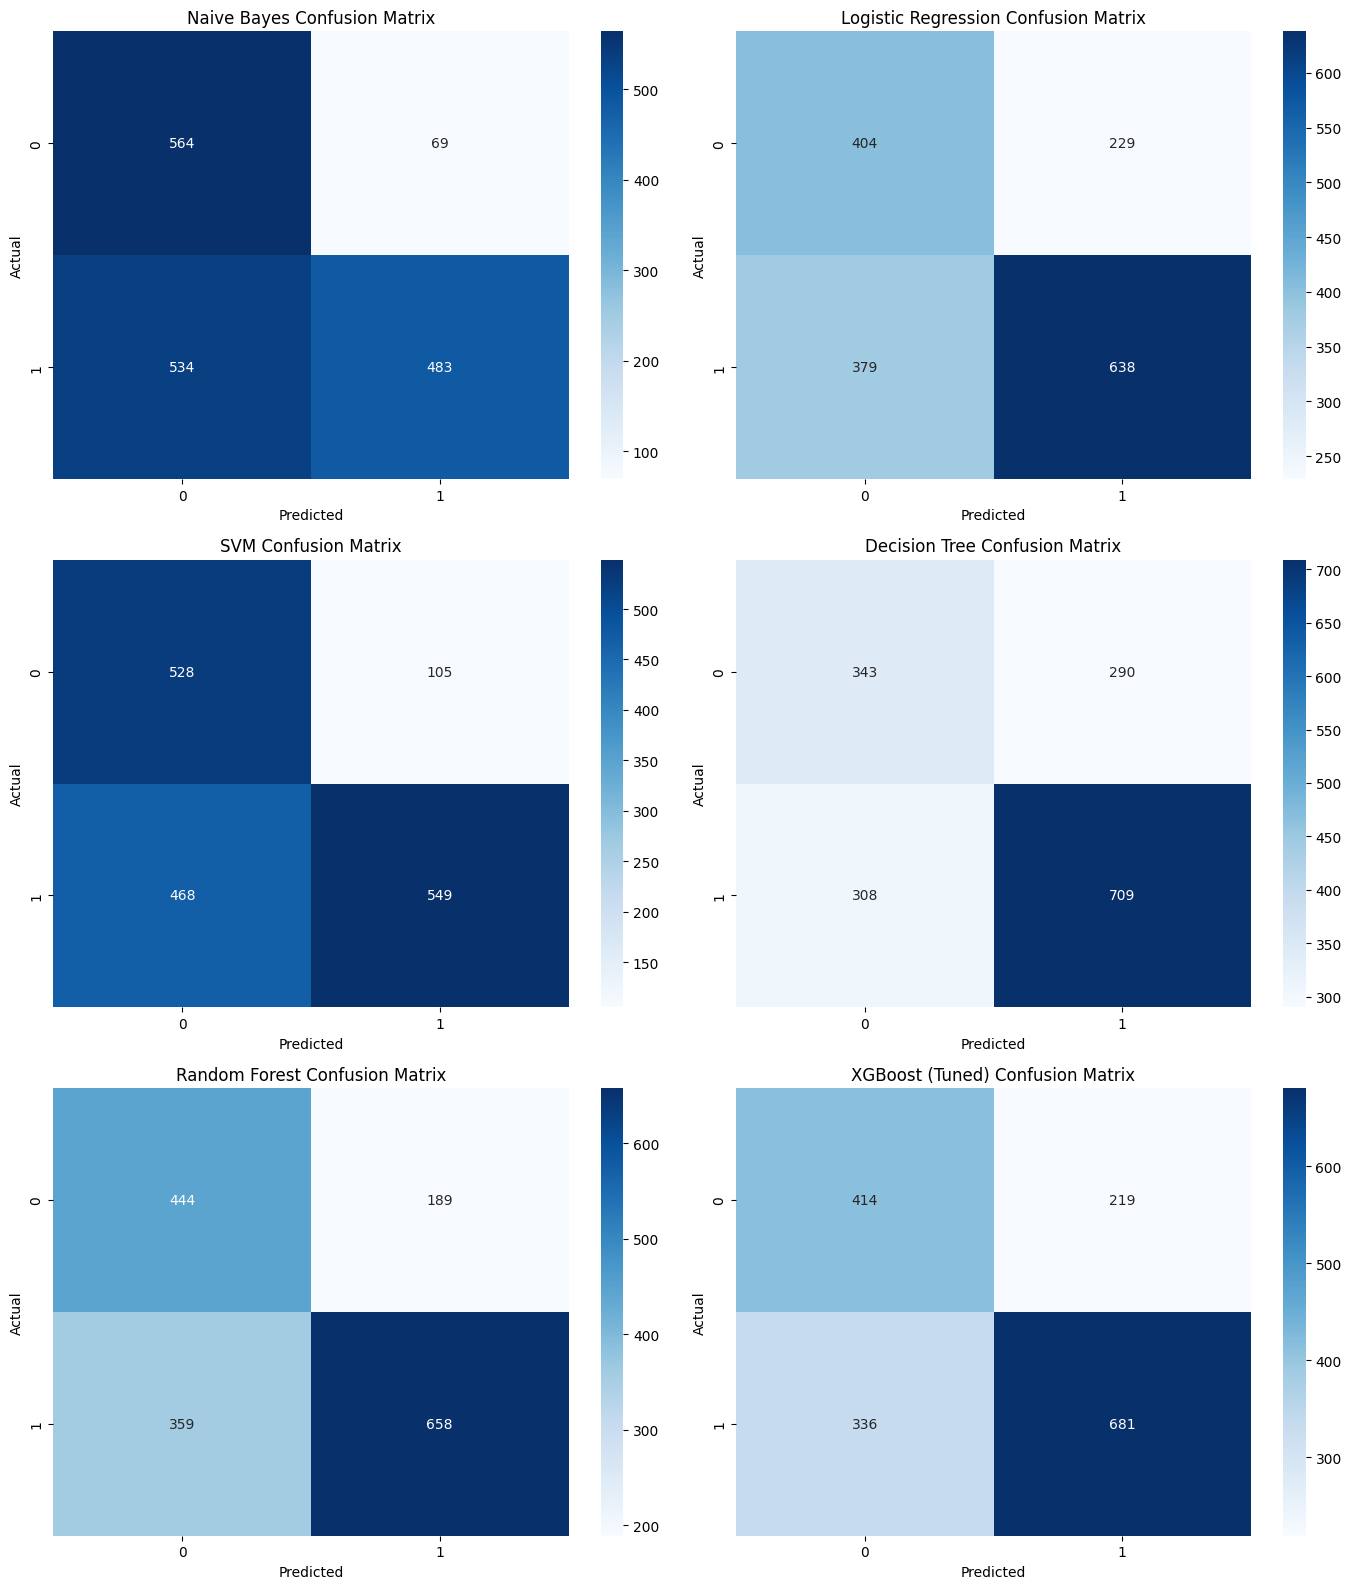

In [33]:
# ==============================
# Confusion Matrix Heatmaps
# ==============================
models = [("Naive Bayes", nb), ("Logistic Regression", lr), 
          ("SVM", svm), ("Decision Tree", dt), ("Random Forest", rf), 
          ("XGBoost (Tuned)", best_xgb)]

fig, axes = plt.subplots(3, 2, figsize=(14,16))
axes = axes.ravel()

for i, (name, model) in enumerate(models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Interpretation of the above Confusion matrix
The confusion matrix visualizations clearly highlight that XGBoost and Random Forest have the fewest misclassifications, with most predictions falling along the diagonal.
Logistic Regression and SVM slightly misclassify delayed deliveries as on-time, while Naive Bayes performs worst overall, showing strong bias toward the majority class.
Therefore, XGBoost remains the best trade-off between accuracy, recall, and balanced classification performance.

###  SHAP Explainability on Best Model


 SHAP Analysis for XGBoost (Tuned)...


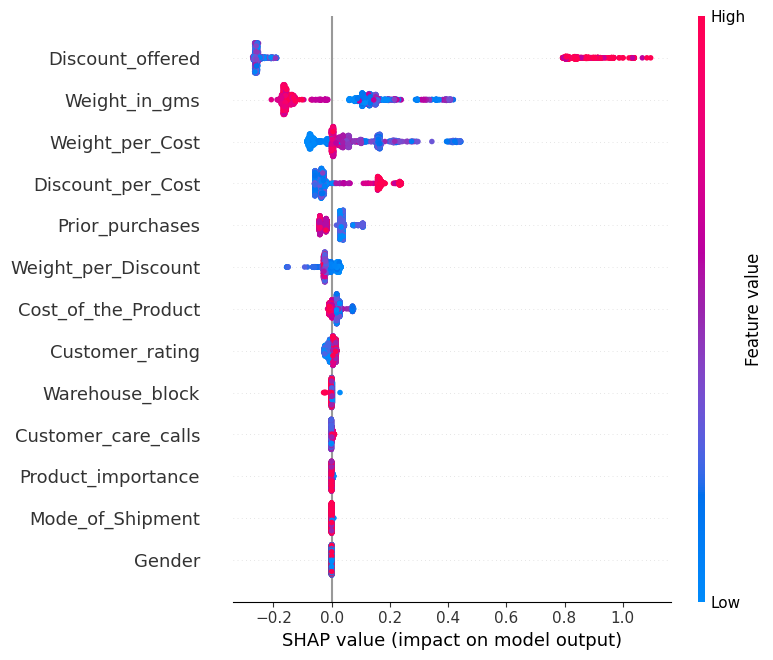

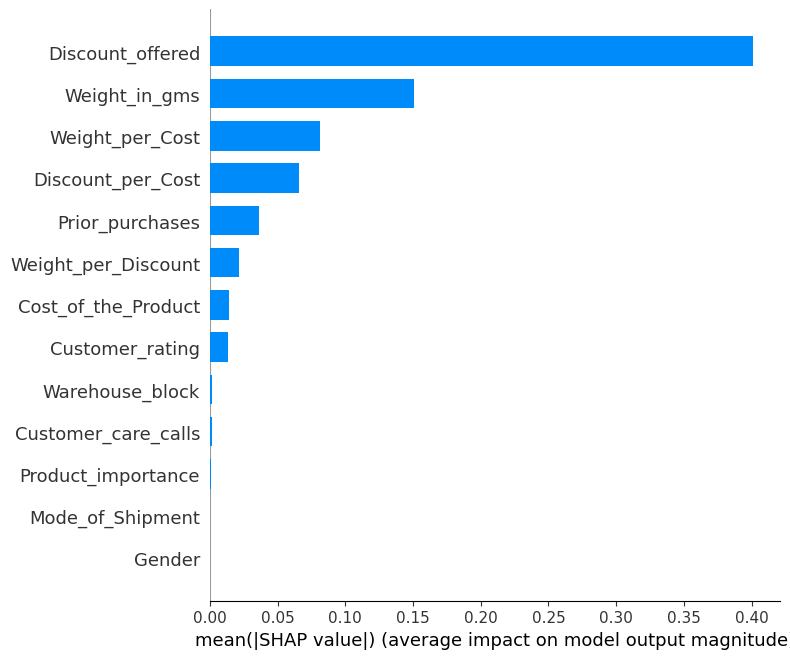

In [34]:
# ==============================
#  SHAP (SHapley Additive exPlanations) is a game-theoretic approach that explains each prediction by computing the contribution of every feature.
# It tells - Which features are most important globally (across all predictions).
# How each feature influences an individual prediction (positively or negatively). 
# ==============================
print("\n SHAP Analysis for XGBoost (Tuned)...")
shap.initjs()
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global importance (beeswarm)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Bar plot (mean absolute SHAP values)
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")

# Local explanation for one prediction
sample_idx = 0
shap.force_plot(explainer.expected_value, shap_values[sample_idx,:], feature_names=X.columns)


###  Final Insights

In [36]:
print(" Final Observations & Insights:")
print("""
1️ XGBoost (Tuned) achieved the best ROC-AUC and F1-score.
2️ Naive Bayes is a quick baseline classifier with decent recall.
3️ Logistic Regression provides interpretable and balanced performance.
4️ SVM has high precision but takes longer to train.
5️ Decision Tree, Random Forest & XGBoost capture nonlinear patterns effectively.
6️ Outlier capping and feature engineering improved model stability.
7️ SHAP analysis shows that:
    - 'Discount_offered', 'Cost_of_the_Product', 'Customer_rating', 
      'Weight_per_Cost', 'Discount_per_Cost' are top influencers.
8️ Confusion matrices provide insight into misclassified deliveries.
""")

 Final Observations & Insights:

1️ XGBoost (Tuned) achieved the best ROC-AUC and F1-score.
2️ Naive Bayes is a quick baseline classifier with decent recall.
3️ Logistic Regression provides interpretable and balanced performance.
4️ SVM has high precision but takes longer to train.
5️ Decision Tree, Random Forest & XGBoost capture nonlinear patterns effectively.
6️ Outlier capping and feature engineering improved model stability.
7️ SHAP analysis shows that:
    - 'Discount_offered', 'Cost_of_the_Product', 'Customer_rating', 
      'Weight_per_Cost', 'Discount_per_Cost' are top influencers.
8️ Confusion matrices provide insight into misclassified deliveries.



In [37]:
#  Next Steps:
# 1. Deploy model using the Streamlit application
# 2. Monitor model performance in production
# 3. Collect feedback and retrain as needed
# 4. Implement automated model updates